# DIGITAL TRANSACTION RISK ANALYSIS
## Unit II: Descriptive Statistics and Data Dimensionality

In this unit, we perform a detailed comparison of summary statistics across different data transformations (Original vs. Log-Transformed). We also explore the dimensionality of the dataset through covariance and correlation matrices to understand the relationships between features and the target fraud label.

In [2]:
# ================================================================
# SETUP: DEPENDENCIES AND DATA LOADING
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load the dataset (assumes it exists in the current directory)
try:
    print("Loading dataset... (This may take ~20 seconds)")
    df = pd.read_csv('fraudTrain.csv')
    
    # Pre-processing for Unit II
    df['amt_log_transformed'] = np.log1p(df['amt'])
    
    print("="*40)
    print("DATASET INTEGRITY REPORT")
    print("="*40)
    print(f"Total Rows    : {df.shape[0]:,}")
    print(f"Total Columns : {df.shape[1]}")
    print(f"Memory Usage  : {df.memory_usage().sum() / 1024**2:.2f} MB")
    print("\nKey Features Loaded:")
    print(list(df.columns[:10]), "...")
    print("\nStatus: Dataset loaded correctly. Preview below:")
    display(df.head())
except FileNotFoundError:
    print("Error: fraudTrain.csv not found in this directory.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Loading dataset... (This may take ~20 seconds)
DATASET INTEGRITY REPORT
Total Rows    : 1,296,675
Total Columns : 24
Memory Usage  : 237.43 MB

Key Features Loaded:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street'] ...

Status: Dataset loaded correctly. Preview below:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,amt_log_transformed
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,1.786747
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,4.684259
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,5.398660
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,3.828641
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,3.760269


# UNIT II: Descriptive Statistics and Data Dimensionality

This section focuses on summarizing the data distribution and checking relationships between variables.


UNIT II: VISUAL COMPARISON OF SUMMARY STATISTICS


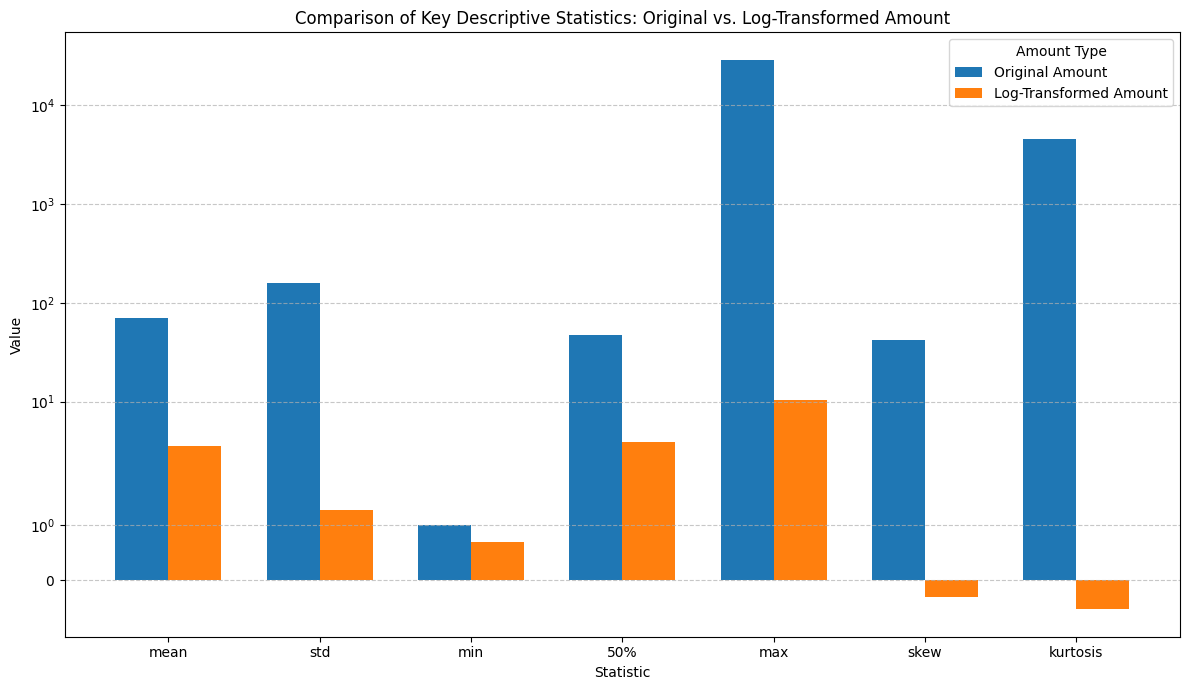

Interpretation: the transformed amount compresses the extreme tail and is easier to compare with the original values.


In [3]:
print('\n' + '='*48)
print('UNIT II: VISUAL COMPARISON OF SUMMARY STATISTICS')
print('='*48)

# Recalculate summary stats for visualization
stats_original = df['amt'].describe()
stats_log      = df['amt_log_transformed'].describe()

comparison_df = pd.DataFrame({
    'Statistic': ['mean', 'std', 'min', '50%', 'max', 'skew', 'kurtosis'],
    'Original Amount': [
        stats_original['mean'], stats_original['std'], stats_original['min'], 
        stats_original['50%'], stats_original['max'], df['amt'].skew(), df['amt'].kurtosis()
    ],
    'Log-Transformed Amount': [
        stats_log['mean'], stats_log['std'], stats_log['min'], 
        stats_log['50%'], stats_log['max'], df['amt_log_transformed'].skew(), df['amt_log_transformed'].kurtosis()
    ]
})

plot_df = comparison_df.melt(id_vars='Statistic', var_name='Transformation', value_name='Value')

fig, ax = plt.subplots(figsize=(12, 7))
transformations = plot_df['Transformation'].unique()
stat_order = comparison_df['Statistic'].tolist()
bar_width = 0.35
positions = range(len(stat_order))

for index, transformation in enumerate(transformations):
    subset = plot_df[plot_df['Transformation'] == transformation].set_index('Statistic').reindex(stat_order)
    offsets = [position + (index - 0.5) * bar_width for position in positions]
    ax.bar(offsets, subset['Value'], width=bar_width, label=transformation)

ax.set_title('Comparison of Key Descriptive Statistics: Original vs. Log-Transformed Amount')
ax.set_xlabel('Statistic')
ax.set_ylabel('Value')
ax.set_yscale('symlog')
ax.set_xticks(list(positions))
ax.set_xticklabels(stat_order)
ax.legend(title='Amount Type')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('Interpretation: the transformed amount compresses the extreme tail and is easier to compare with the original values.')

## Covariance, Correlation, and Dimensional Summary

This section checks covariance, correlation, and the distribution of key numeric features across the dataset.

In [4]:
print('\n' + '='*48)
print('UNIT II: COVARIANCE, CORRELATION, AND DIMENSIONAL SUMMARY')
print('='*48)

key_features = ['amt', 'amt_log_transformed', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'is_fraud']
available_features = [col for col in key_features if col in df.columns]

dimensional_summary = df[available_features].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
print('\nDimensional summary for the selected numeric features:')
print(dimensional_summary.round(3).to_string())

cov_matrix = df[available_features].cov()
corr_matrix = df[available_features].corr()

print('\nCovariance matrix:')
print(cov_matrix.round(3).to_string())

print('\nCorrelation matrix:')
print(corr_matrix.round(3).to_string())

if 'is_fraud' in corr_matrix.columns:
    fraud_correlations = corr_matrix['is_fraud'].drop('is_fraud').abs().sort_values(ascending=False)
    print('\nStrongest absolute correlations with is_fraud:')
    print(fraud_correlations.head(5).round(3).to_string())



UNIT II: COVARIANCE, CORRELATION, AND DIMENSIONAL SUMMARY

Dimensional summary for the selected numeric features:
                         count       mean    median         std      min          max
amt                  1296675.0     70.351    47.520     160.316    1.000    28948.900
amt_log_transformed  1296675.0      3.533     3.882       1.289    0.693       10.273
city_pop             1296675.0  88824.441  2456.000  301956.361   23.000  2906700.000
lat                  1296675.0     38.538    39.354       5.076   20.027       66.693
long                 1296675.0    -90.226   -87.477      13.759 -165.672      -67.950
merch_lat            1296675.0     38.537    39.366       5.110   19.028       67.510
merch_long           1296675.0    -90.226   -87.438      13.771 -166.671      -66.951
is_fraud             1296675.0      0.006     0.000       0.076    0.000        1.000

Covariance matrix:
                            amt  amt_log_transformed      city_pop         lat        long 

In [5]:
print('\n' + '='*48)
print('UNIT II: DATA INTERPRETATION')
print('='*48)

print("The covariance values describe how numeric variables move together. Correlation is more useful because it standardizes the relationship between variables.")
print("\nOverall, the analysis suggests that fraud cannot be explained by a single variable alone.")
print("=" * 60)
print("UNIT II COMPLETE")
print("=" * 60)


UNIT II: DATA INTERPRETATION
The covariance values describe how numeric variables move together. Correlation is more useful because it standardizes the relationship between variables.

Overall, the analysis suggests that fraud cannot be explained by a single variable alone.
UNIT II COMPLETE
